In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
df = pd.read_csv("UberDataset.csv")

df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [3]:
df['PURPOSE'].fillna("Unknown", inplace=True)
df['START_DATE'] = pd.to_datetime(df['START_DATE'], errors='coerce')


df['hour'] = df['START_DATE'].dt.hour
df['month'] = df['START_DATE'].dt.month


df.dropna(inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 421 entries, 0 to 1047
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   START_DATE  421 non-null    datetime64[ns]
 1   END_DATE    421 non-null    object        
 2   CATEGORY    421 non-null    object        
 3   START       421 non-null    object        
 4   STOP        421 non-null    object        
 5   MILES       421 non-null    float64       
 6   PURPOSE     421 non-null    object        
 7   hour        421 non-null    float64       
 8   month       421 non-null    float64       
dtypes: datetime64[ns](1), float64(3), object(5)
memory usage: 32.9+ KB


C:\Users\VINU\AppData\Local\Temp\ipykernel_2900\2447818468.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['PURPOSE'].fillna("Unknown", inplace=True)


In [4]:
le = LabelEncoder()

df['CATEGORY'] = le.fit_transform(df['CATEGORY'])
df['PURPOSE'] = le.fit_transform(df['PURPOSE'])

In [5]:
X = df[['MILES', 'hour', 'month', 'PURPOSE']]
y = df['CATEGORY']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [8]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9647058823529412


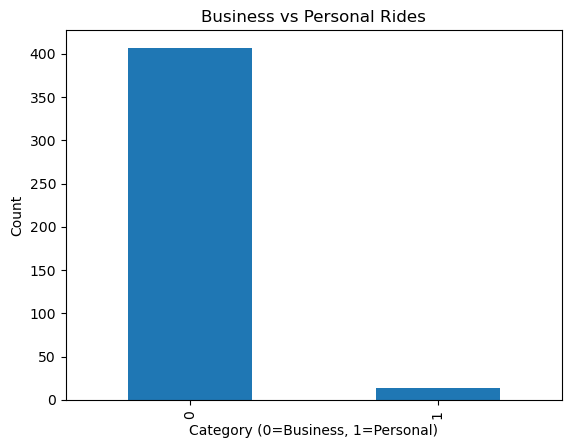

In [9]:
plt.figure()

df['CATEGORY'].value_counts().plot(kind='bar')

plt.title("Business vs Personal Rides")
plt.xlabel("Category (0=Business, 1=Personal)")
plt.ylabel("Count")

plt.show()

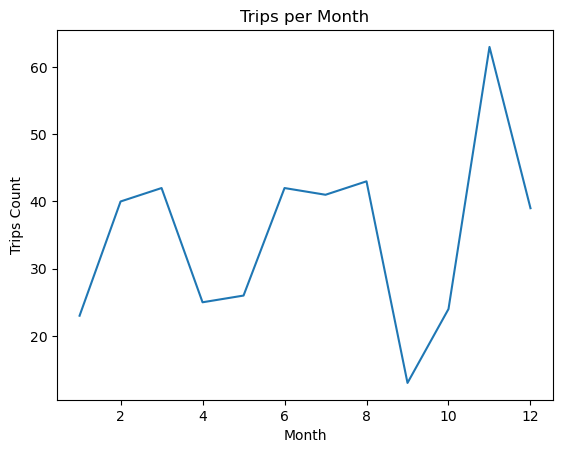

In [10]:
plt.figure()

df.groupby('month').size().plot()

plt.title("Trips per Month")
plt.xlabel("Month")
plt.ylabel("Trips Count")

plt.show()

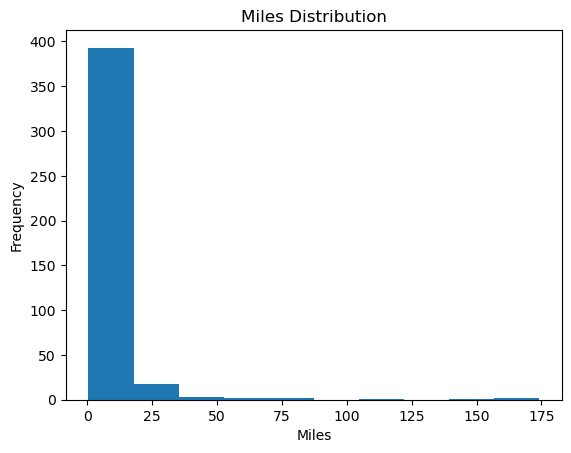

In [11]:
plt.figure()

plt.hist(df['MILES'])

plt.title("Miles Distribution")
plt.xlabel("Miles")
plt.ylabel("Frequency")

plt.show()

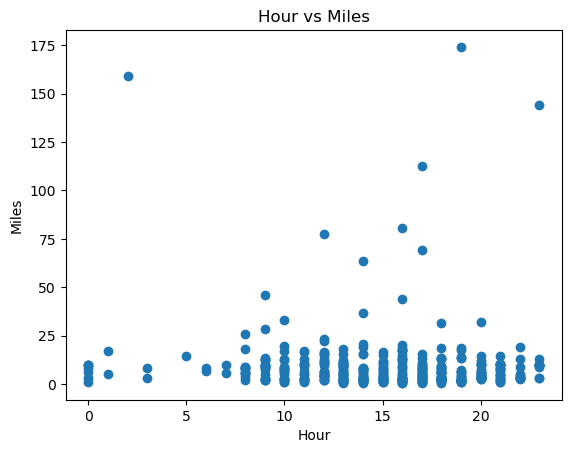

In [12]:
plt.figure()

plt.scatter(df['hour'], df['MILES'])

plt.title("Hour vs Miles")
plt.xlabel("Hour")
plt.ylabel("Miles")

plt.show()

<Figure size 640x480 with 0 Axes>

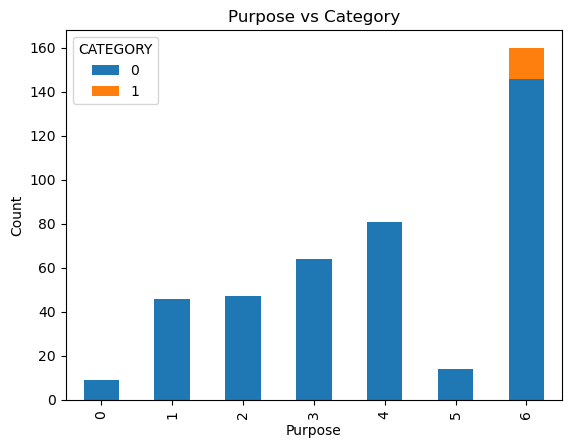

In [13]:
plt.figure()

pd.crosstab(df['PURPOSE'], df['CATEGORY']).plot(kind='bar', stacked=True)

plt.title("Purpose vs Category")
plt.xlabel("Purpose")
plt.ylabel("Count")

plt.show()

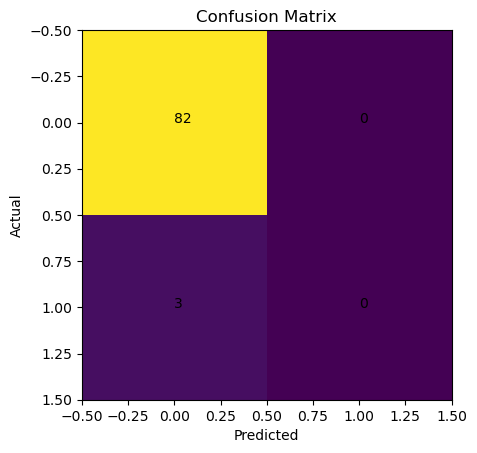

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i][j])

plt.show()

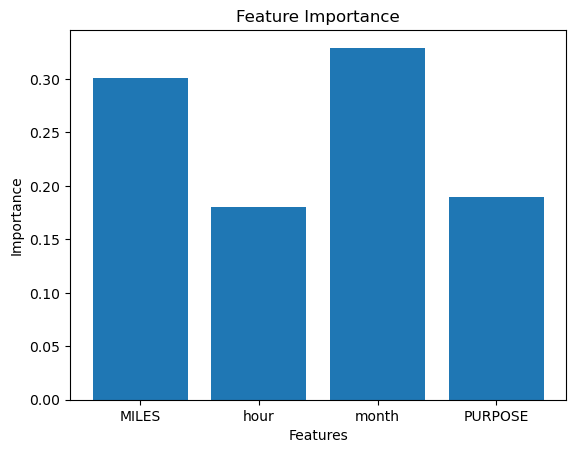

In [16]:
plt.figure()

features = ['MILES', 'hour', 'month', 'PURPOSE']
importance = model.feature_importances_

plt.bar(features, importance)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()